# Batch integration benchmark - Harmony vs scVI (heart atlas)

The heart atlas mixes four cell-isolation protocols (`cell_source`), a technical
**batch effect**. We compare plain PCA, **Harmony** (fast linear correction), and
**scVI** (a deep generative model on raw counts).

> Launch from the project folder: `cd scvi_integration && .venv/bin/jupyter lab`

## 1. Load and keep raw counts

scVI models raw counts, so we stash them before normalizing. Subsampled for CPU speed.

In [1]:
import numpy as np
import scanpy as sc
import scvi
import harmonypy

BATCH = 'cell_source'
CELLTYPE = 'cell_type'

adata = scvi.data.heart_cell_atlas_subsampled()
sc.pp.subsample(adata, n_obs=12000, random_state=0)
adata.layers['counts'] = adata.X.copy()
print('cells:', adata.n_obs, ' protocols:', adata.obs[BATCH].nunique())
adata.obs[BATCH].value_counts()

/Users/komlagnona/Desktop/MYDESK/SENSORIUM/scvi_integration/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO     File data/hca_subsampled_20k.h5ad already downloaded                                                      


cells: 12000  protocols: 4


cell_source
Sanger-Nuclei     4444
Harvard-Nuclei    4353
Sanger-CD45       2029
Sanger-Cells      1174
Name: count, dtype: int64

## 2. Preprocess and PCA (the baseline)

In [2]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3',
                            layer='counts', subset=True)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.pca(adata)
print('PCA done:', adata.obsm['X_pca'].shape)

PCA done: (12000, 50)


## 3. Harmony

A fast linear correction of the PCA. harmonypy returns cells-by-components, so no transpose.

In [3]:
ho = harmonypy.run_harmony(adata.obsm['X_pca'], adata.obs, [BATCH])
adata.obsm['X_pca_harmony'] = np.asarray(ho.Z_corr)
print('Harmony done:', adata.obsm['X_pca_harmony'].shape)

2026-07-13 23:26:24,036 - harmonypy - INFO - Running Harmony


2026-07-13 23:26:24,037 - harmonypy - INFO -   Parameters:


2026-07-13 23:26:24,037 - harmonypy - INFO -     max_iter_harmony: 10


2026-07-13 23:26:24,037 - harmonypy - INFO -     max_iter_kmeans: 4


2026-07-13 23:26:24,037 - harmonypy - INFO -     epsilon_cluster: 0.001


...

2026-07-13 23:26:24,442 - harmonypy - INFO - Iteration 2 of 10


2026-07-13 23:26:24,616 - harmonypy - INFO - Iteration 3 of 10


2026-07-13 23:26:24,790 - harmonypy - INFO - Iteration 4 of 10


2026-07-13 23:26:24,965 - harmonypy - INFO - Converged after 4 iterations


Harmony done: (12000, 50)


## 4. scVI

Train on the raw counts with the protocol as the batch key. A few minutes on CPU.

In [4]:
scvi.model.SCVI.setup_anndata(adata, layer='counts', batch_key=BATCH)
model = scvi.model.SCVI(adata)
model.train(max_epochs=40)
adata.obsm['X_scVI'] = model.get_latent_representation()
print('scVI latent:', adata.obsm['X_scVI'].shape)

/Users/komlagnona/Desktop/MYDESK/SENSORIUM/scvi_integration/.venv/lib/python3.13/site-packages/scvi/train/_trainrunner.py:98: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


/Users/komlagnona/Desktop/MYDESK/SENSORIUM/scvi_integration/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


/Users/komlagnona/Desktop/MYDESK/SENSORIUM/scvi_integration/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/komlagnona/Desktop/MYDESK/SENSORIUM/scvi_integration/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training:   0%|          | 0/40 [00:00<?, ?it/s]

...

Epoch 40/40: 100%|██████████| 40/40 [01:12<00:00,  1.92s/it, v_num=1, train_loss=461]

Epoch 40/40: 100%|██████████| 40/40 [01:12<00:00,  1.92s/it, v_num=1, train_loss=461]

`Trainer.fit` stopped: `max_epochs=40` reached.


Epoch 40/40: 100%|██████████| 40/40 [01:12<00:00,  1.81s/it, v_num=1, train_loss=461]


scVI latent: (12000, 10)


## 5. Score each representation

- **batch mixing entropy**: entropy of batch labels among each cell's neighbours (higher = better mixed).
- **cell-type silhouette**: how distinct the cell types are (higher = biology kept).

We also compute a UMAP for each, to plot next.

In [5]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

def batch_mixing_entropy(embedding, batch_labels, k=30):
    codes = batch_labels.astype('category').cat.codes.values
    n_batches = codes.max() + 1
    nbrs = NearestNeighbors(n_neighbors=k).fit(embedding).kneighbors(embedding, return_distance=False)
    ent = []
    for row in nbrs:
        p = np.bincount(codes[row], minlength=n_batches)
        p = p[p > 0] / len(row)
        ent.append(-(p * np.log(p)).sum())
    return float(np.mean(ent)) / np.log(n_batches)

methods = [('PCA (baseline)', 'X_pca'), ('Harmony', 'X_pca_harmony'), ('scVI', 'X_scVI')]

import pandas as pd

summary = []
for name, rep in methods:
    mix = batch_mixing_entropy(adata.obsm[rep], adata.obs[BATCH])
    bio = silhouette_score(adata.obsm[rep], adata.obs[CELLTYPE])
    summary.append({'Method': name,
                    'batch-mixing': round(mix, 3),
                    'cell-type silhouette': round(bio, 3)})
    sc.pp.neighbors(adata, use_rep=rep)
    sc.tl.umap(adata)
    adata.obsm['umap_' + rep] = adata.obsm['X_umap'].copy()

pd.DataFrame(summary)

/Users/komlagnona/Desktop/MYDESK/SENSORIUM/scvi_integration/.venv/lib/python3.13/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,Method,batch-mixing,cell-type silhouette
0,PCA (baseline),0.212036,0.151
1,Harmony,0.382080,0.171
2,scVI,0.337891,0.277


## 6. Compare the UMAPs

Rows = PCA, Harmony, scVI; left coloured by protocol (batch), right by cell type.

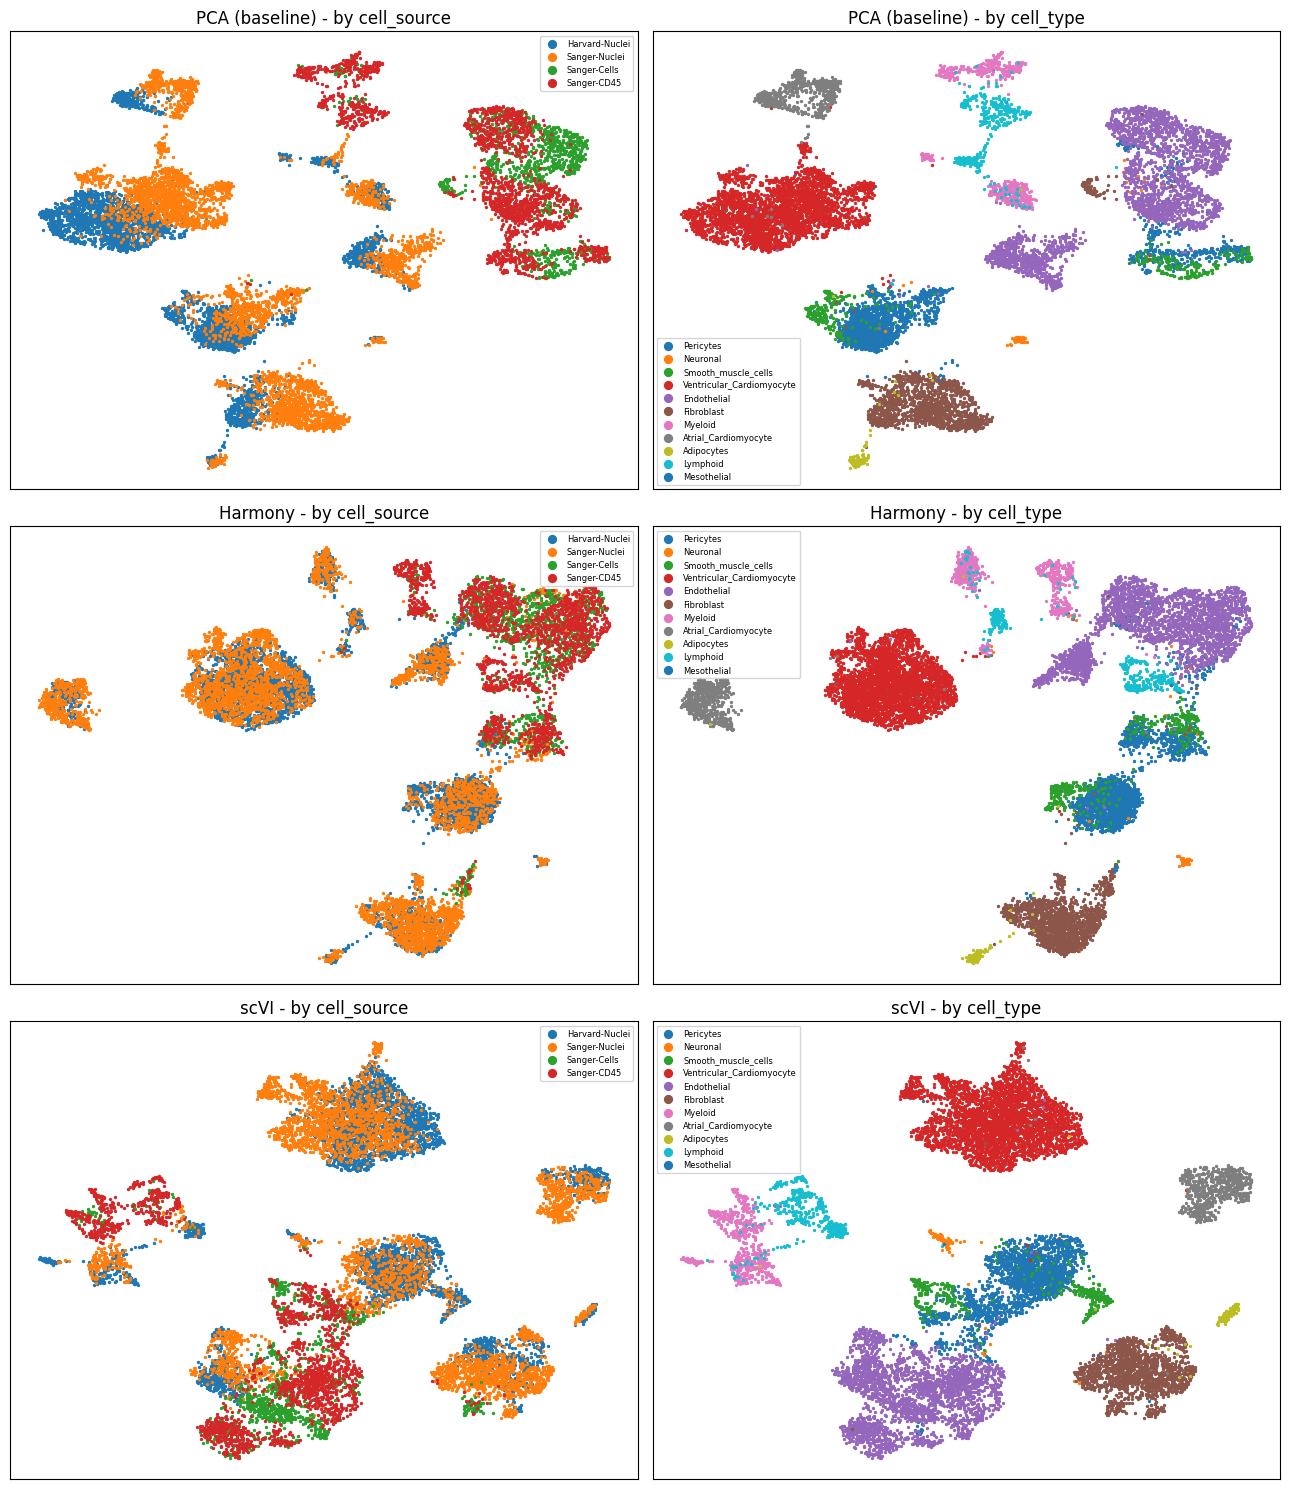

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(methods), 2, figsize=(13, 15))
for row, (name, rep) in enumerate(methods):
    for col, color in enumerate([BATCH, CELLTYPE]):
        ax = axes[row][col]
        coords = adata.obsm['umap_' + rep]
        for value in adata.obs[color].unique():
            mask = (adata.obs[color] == value).values
            ax.scatter(coords[mask, 0], coords[mask, 1], s=2, label=str(value))
        ax.set_title('%s - by %s' % (name, color))
        ax.set_xticks([]); ax.set_yticks([])
        ax.legend(markerscale=4, fontsize=6, loc='best')
plt.tight_layout()
plt.show()

## What the result shows

A trade-off: Harmony mixes the batches most aggressively, while scVI gives the
cleaner biological representation (higher cell-type structure). Both beat PCA.

The CD45-sorted cells stay somewhat separate even after integration - correctly,
since CD45 sorting enriches immune cells, so that difference is biological, not a
technical batch.

## 7. Cell typing with scANVI

scVI gave the cleanest biology, so we build cell typing on it. **scANVI** is its
semi-supervised extension. To test it honestly we hide 30% of the labels (the
query), train on the rest (the reference), and predict the hidden cells.

In [7]:
# hide 30% of labels to act as the unlabelled query
rng = np.random.default_rng(0)
is_query = rng.random(adata.n_obs) < 0.30
adata.obs['labels'] = adata.obs[CELLTYPE].astype(str)
adata.obs.loc[is_query, 'labels'] = 'Unknown'
print('reference:', int((~is_query).sum()), ' query (hidden):', int(is_query.sum()))

scanvi_model = scvi.model.SCANVI.from_scvi_model(
    model, labels_key='labels', unlabeled_category='Unknown')
scanvi_model.train(max_epochs=20)
adata.obs['predicted'] = scanvi_model.predict()

reference: 8414  query (hidden): 3586
INFO     Training for 20 epochs.                                                                                   


/Users/komlagnona/Desktop/MYDESK/SENSORIUM/scvi_integration/.venv/lib/python3.13/site-packages/scvi/train/_trainrunner.py:98: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


/Users/komlagnona/Desktop/MYDESK/SENSORIUM/scvi_integration/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


/Users/komlagnona/Desktop/MYDESK/SENSORIUM/scvi_integration/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/komlagnona/Desktop/MYDESK/SENSORIUM/scvi_integration/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


...

Epoch 20/20:  95%|█████████▌| 19/20 [00:48<00:02,  2.54s/it, v_num=1, train_loss=458]

Epoch 20/20: 100%|██████████| 20/20 [00:51<00:00,  2.54s/it, v_num=1, train_loss=458]

Epoch 20/20: 100%|██████████| 20/20 [00:51<00:00,  2.54s/it, v_num=1, train_loss=458]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|██████████| 20/20 [00:51<00:00,  2.56s/it, v_num=1, train_loss=458]

## 8. Score the predictions on the held-out cells

The hidden cells were never labelled during training, so this is an honest test.

In [8]:
from sklearn.metrics import accuracy_score, classification_report

truth = adata.obs[CELLTYPE].astype(str)[is_query]
pred = adata.obs['predicted'][is_query]
print('accuracy on hidden query cells: %.3f' % accuracy_score(truth, pred))
print()
print(classification_report(truth, pred, zero_division=0))

accuracy on hidden query cells: 0.982

                           precision    recall  f1-score   support

               Adipocytes       1.00      0.92      0.96        25
     Atrial_Cardiomyocyte       0.99      0.99      0.99       192
              Endothelial       0.99      0.99      0.99       828
               Fibroblast       0.98      0.99      0.99       474
                 Lymphoid       0.98      0.94      0.96       125
              Mesothelial       1.00      0.75      0.86         4
                  Myeloid       0.96      0.99      0.98       195
                 Neuronal       0.97      0.90      0.93        31
                Pericytes       0.97      0.96      0.97       594
      Smooth_muscle_cells       0.88      0.89      0.88       103
Ventricular_Cardiomyocyte       1.00      1.00      1.00      1015

                 accuracy                           0.98      3586
                macro avg       0.97      0.94      0.95      3586
             weighted

## 9. UMAP: true vs predicted labels

One colour per cell type, shared across both panels, so a match shows as identical colours.

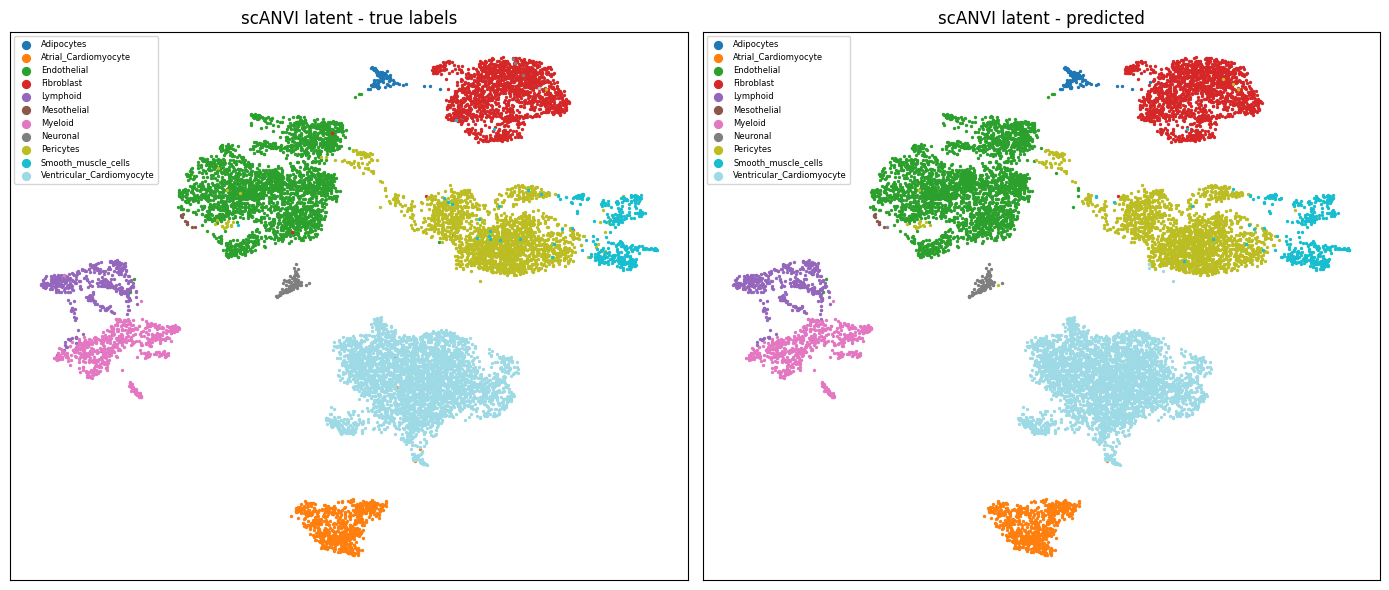

In [9]:
adata.obsm['X_scANVI'] = scanvi_model.get_latent_representation()
sc.pp.neighbors(adata, use_rep='X_scANVI')
sc.tl.umap(adata)

cell_types = sorted(set(adata.obs[CELLTYPE]) | set(adata.obs['predicted']))
color_map = dict(zip(cell_types, plt.cm.tab20(np.linspace(0, 1, len(cell_types)))))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, color in zip(axes, [CELLTYPE, 'predicted']):
    coords = adata.obsm['X_umap']
    for value in cell_types:
        mask = (adata.obs[color] == value).values
        ax.scatter(coords[mask, 0], coords[mask, 1], s=2, color=color_map[value], label=value)
    ax.set_title('scANVI latent - %s' % ('true labels' if color == CELLTYPE else 'predicted'))
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(markerscale=4, fontsize=6, loc='best')
plt.tight_layout()
plt.show()